<h1 align='center'>Breast Cancer Prediction Model</h1>

In [ ]:
!pip install sickit-learn --upgrade --quite

In [ ]:
pip install opendatasets

Downladoing opendataset to download dataset from kaggle

In [10]:
import opendatasets as od

In [11]:
url="https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data"
od.download(url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data


100%|██████████| 48.6k/48.6k [00:00<00:00, 1.45MB/s]

In [16]:
import os
os.listdir('./breast-cancer-wisconsin-data')


['data.csv']

In [52]:
!pip install pandas --upgrade --quiet
import pandas as pd
Cancer_Data_Df=pd.read_csv('./breast-cancer-wisconsin-data/data.csv')

In [53]:

Cancer_Data_Df=Cancer_Data_Df.drop('id', axis=1)
Cancer_Data_Df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [49]:
Cancer_Data_Df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                0 non-null      float64
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [29]:
!pip install plotly matplotlib seaborn --quiet

In [30]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [54]:
Cancer_Data_Df['diagnosis']=Cancer_Data_Df['diagnosis'].map({'M':1, 'B':0})
Cancer_Data_Df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [56]:

Cancer_Data_Df=Cancer_Data_Df.drop('Unnamed: 32', axis=1)
Cancer_Data_Df


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [77]:
print(Cancer_Data_Df.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
radius_se                  0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [57]:
corr=Cancer_Data_Df.corr()['diagnosis']

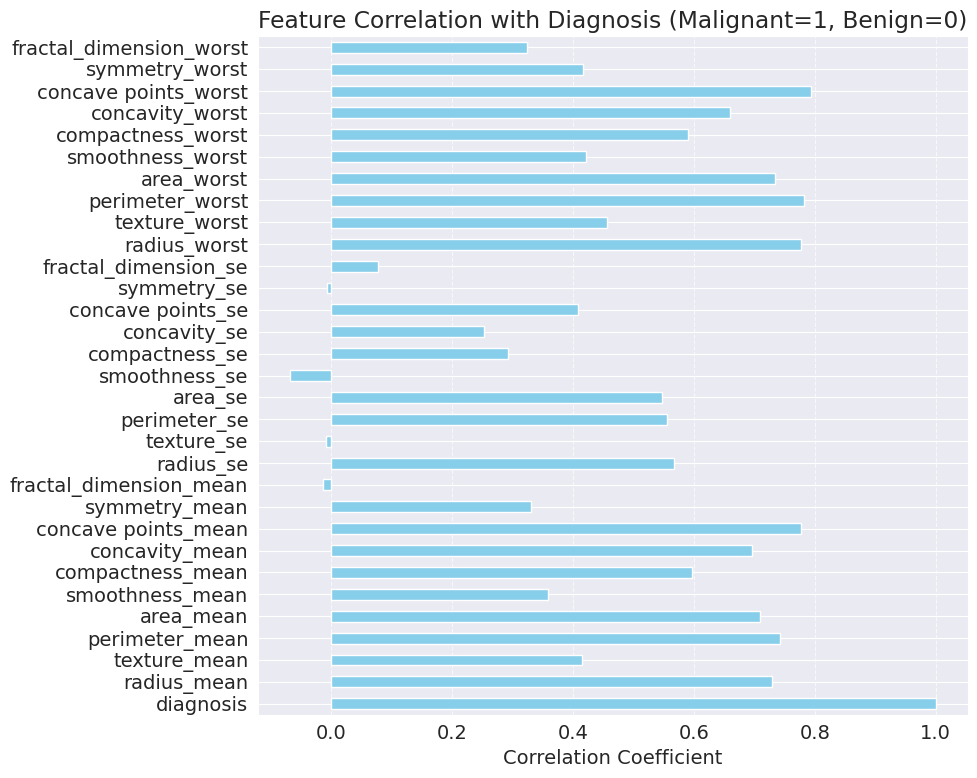

In [58]:
import matplotlib.pyplot as plt

# Drop 'diagnosis' so it doesn't compare with itself (which would just be 1.0)
#arget_corr = correlations.drop('diagnosis').sort_values()

# Plot horizontal bar graph
plt.figure(figsize=(10, 8))
corr.plot(kind='barh', color='skyblue')
plt.title('Feature Correlation with Diagnosis (Malignant=1, Benign=0)')
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [59]:
low_corr=[
    'symmetry_se',
    'texture_se',
    'fractal_dimension_mean'
]
Cancer_Data_Df=Cancer_Data_Df.drop(columns=low_corr)

In [61]:
from sklearn.model_selection import train_test_split

In [69]:
Cancer_Train_Data, Cancer_Test_Data = train_test_split(Cancer_Data_Df, test_size=0.2, random_state=50 )

In [70]:
Cancer_Test_Data


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,radius_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
356,0,13.05,18.59,85.09,512.0,0.10820,0.13040,0.096030,0.05603,0.2035,0.3106,2.590,21.57,0.007807,0.03932,0.051120,0.018760,0.005715,14.19,24.85,94.22,591.2,0.1343,0.2658,0.25730,0.12580,0.3113,0.08317
556,0,10.16,19.59,64.73,311.7,0.10030,0.07504,0.005025,0.01116,0.1791,0.2441,1.648,16.80,0.012910,0.02222,0.004174,0.007082,0.002278,10.65,22.88,67.88,347.3,0.1265,0.1200,0.01005,0.02232,0.2262,0.06742
283,1,16.24,18.77,108.80,805.1,0.10660,0.18020,0.194800,0.09052,0.1876,0.2873,2.464,28.09,0.004563,0.03481,0.038720,0.012090,0.004081,18.55,25.09,126.90,1031.0,0.1365,0.4706,0.50260,0.17320,0.2770,0.10630
495,0,14.87,20.21,96.12,680.9,0.09587,0.08345,0.068240,0.04951,0.1487,0.2323,1.596,21.84,0.005415,0.01371,0.021530,0.011830,0.001812,16.01,28.48,103.90,783.6,0.1216,0.1388,0.17000,0.10170,0.2369,0.06599
364,0,13.40,16.95,85.48,552.4,0.07937,0.05696,0.021810,0.01473,0.1650,0.1584,1.036,13.22,0.004394,0.01250,0.014510,0.005484,0.002074,14.73,21.70,93.76,663.5,0.1213,0.1676,0.13640,0.06987,0.2741,0.07582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,1,14.95,17.57,96.85,678.1,0.11670,0.13050,0.153900,0.08624,0.1957,1.2960,8.419,101.90,0.010000,0.03480,0.065770,0.028010,0.002887,18.55,21.43,121.40,971.4,0.1411,0.2164,0.33550,0.16670,0.3414,0.07147
208,0,13.11,22.54,87.02,529.4,0.10020,0.14830,0.087050,0.05102,0.1850,0.1931,1.491,15.09,0.005251,0.03041,0.025260,0.008304,0.004198,14.55,29.16,99.48,639.3,0.1349,0.4402,0.31620,0.11260,0.4128,0.10760
24,1,16.65,21.38,110.00,904.6,0.11210,0.14570,0.152500,0.09170,0.1995,0.8068,5.455,102.60,0.006048,0.01882,0.027410,0.011300,0.002801,26.46,31.56,177.00,2215.0,0.1805,0.3578,0.46950,0.20950,0.3613,0.09564
264,1,17.19,22.07,111.60,928.3,0.09726,0.08995,0.090610,0.06527,0.1867,0.4203,2.819,45.42,0.004493,0.01206,0.020480,0.009875,0.001575,21.58,29.33,140.50,1436.0,0.1558,0.2567,0.38890,0.19840,0.3216,0.07570


In [71]:
Cancer_Train_Data

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,radius_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
345,0,10.26,14.71,66.20,321.6,0.09882,0.09159,0.03581,0.02037,0.1633,0.3380,2.3940,19.330,0.017360,0.04671,0.02611,0.012960,0.006758,10.88,19.48,70.89,357.1,0.1360,0.16360,0.07162,0.04074,0.2434,0.08488
107,0,12.36,18.54,79.01,466.7,0.08477,0.06815,0.02643,0.01921,0.1602,0.1199,0.8484,9.227,0.003457,0.01047,0.01167,0.005558,0.001356,13.29,27.49,85.56,544.1,0.1184,0.19630,0.19370,0.08442,0.2983,0.07185
16,1,14.68,20.13,94.74,684.5,0.09867,0.07200,0.07395,0.05259,0.1586,0.4727,3.1950,45.400,0.005718,0.01162,0.01998,0.011090,0.002085,19.07,30.88,123.40,1138.0,0.1464,0.18710,0.29140,0.16090,0.3029,0.08216
361,0,13.30,21.57,85.24,546.1,0.08582,0.06373,0.03344,0.02424,0.1815,0.2621,2.0280,20.980,0.005498,0.02045,0.01795,0.006399,0.001956,14.20,29.20,92.94,621.2,0.1140,0.16670,0.12120,0.05614,0.2637,0.06658
353,1,15.08,25.74,98.00,716.6,0.10240,0.09769,0.12350,0.06553,0.1647,0.6534,4.1740,63.370,0.010520,0.02431,0.04912,0.017460,0.004867,18.51,33.22,121.20,1050.0,0.1660,0.23560,0.40290,0.15260,0.2654,0.09438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,1,18.94,21.31,123.60,1130.0,0.09009,0.10290,0.10800,0.07951,0.1582,0.7888,5.4860,96.050,0.004444,0.01652,0.02269,0.013700,0.001698,24.86,26.58,165.90,1866.0,0.1193,0.23360,0.26870,0.17890,0.2551,0.06589
132,1,16.16,21.54,106.20,809.8,0.10080,0.12840,0.10430,0.05613,0.2160,0.4332,2.8440,43.680,0.004877,0.01952,0.02219,0.009231,0.002373,19.47,31.68,129.70,1175.0,0.1395,0.30550,0.29920,0.13120,0.3480,0.07619
289,0,11.37,18.89,72.17,396.0,0.08713,0.05008,0.02399,0.02173,0.2013,0.2656,1.9540,17.490,0.006538,0.01395,0.01376,0.009924,0.002928,12.36,26.14,79.29,459.3,0.1118,0.09708,0.07529,0.06203,0.3267,0.06994
109,0,11.34,21.26,72.48,396.5,0.08759,0.06575,0.05133,0.01899,0.1487,0.2344,1.5970,16.410,0.009113,0.01557,0.02443,0.006435,0.002477,13.01,29.15,83.99,518.1,0.1699,0.21960,0.31200,0.08278,0.2829,0.08832


In [81]:
Input_Train=Cancer_Train_Data.drop(columns=['diagnosis'])
Target=Cancer_Train_Data['diagnosis']

**Scaling**

In [82]:
from sklearn.preprocessing import StandardScaler

In [83]:
Scaler=StandardScaler()
Scaler.fit(Input_Train)
Scaled_Input_Train=Scaler.transform(Input_Train)

**Model Training**

In [84]:
from sklearn.linear_model import LogisticRegression


In [87]:
model=LogisticRegression()
model.fit(Scaled_Input_Train, Target)

LogisticRegression()

Predictions on trained Data

In [90]:
Trained_Data_Preds=model.predict(Scaled_Input_Train)

In [92]:
from sklearn.metrics import accuracy_score


In [93]:
accuracy_score(Trained_Data_Preds,Target)

0.9846153846153847

98% accurracy on trained data

**Now On Test Data**

In [95]:
Input_Test=Cancer_Test_Data.drop(columns='diagnosis')
Target_Test=Cancer_Test_Data['diagnosis']

In [ ]:
Scaled_Input_Test=Scaler.transform(Input_Test)

In [98]:
Test_Data_Pred=model.predict(Scaled_Input_Test)

In [100]:
accuracy_score(Test_Data_Pred,Target_Test)

1.0

In [102]:
from sklearn.metrics import confusion_matrix

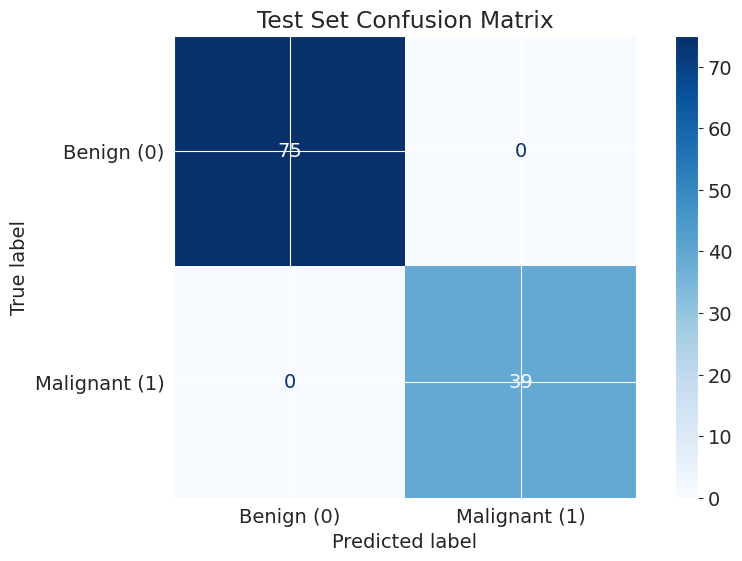

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Test_Data_Pred = model.predict(Scaled_Input_Test)

cm = confusion_matrix(Target_Test, Test_Data_Pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (0)', 'Malignant (1)'])
disp.plot(cmap='Blues')
plt.title("Test Set Confusion Matrix")
plt.show()